## Prepare

In [ ]:
# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

# Install evaluation dependency
!pip install -q torch-fidelity


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os
import math
import random
from time import time, perf_counter
import shutil

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
# from torchvision import datasets, transforms
from torchvision.utils import save_image

import matplotlib.pyplot as plt
from torch_fidelity import calculate_metrics


# -----------------------
# Global config & paths
# -----------------------
EXPERIMENT_NAME = "ECE285b_QuickDraw"
BASE_DIR = "/content"
PROJECT_DIR = os.path.join(BASE_DIR, EXPERIMENT_NAME)

# Where to store artifacts on Google Drive
DRIVE_ROOT = "/content/drive/MyDrive"
DRIVE_PROJECT_DIR = os.path.join(DRIVE_ROOT, EXPERIMENT_NAME)

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(DRIVE_PROJECT_DIR, exist_ok=True)

# Sub-dirs under project
DATA_DIR = os.path.join(PROJECT_DIR, "data")
TEACHER_CKPT_DIR = os.path.join(PROJECT_DIR, "teacher_ckpt")
CONSIST_CKPT_DIR = os.path.join(PROJECT_DIR, "consistency_ckpt")
FLOW_CKPT_DIR = os.path.join(PROJECT_DIR, "flow_ckpt")
SAMPLES_DIR = os.path.join(PROJECT_DIR, "samples")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")

for d in [DATA_DIR, TEACHER_CKPT_DIR, CONSIST_CKPT_DIR, FLOW_CKPT_DIR, SAMPLES_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

QUICKDRAW_NPY_DIR = os.path.join(DATA_DIR, "quickdraw_npy")
os.makedirs(QUICKDRAW_NPY_DIR, exist_ok=True)

NUM_QD_CLASSES = 9
MAX_ITEMS_PER_CLASS = 10000

# Training epochs for all models
EPOCHS_TEACHER = 80
EPOCHS_CONSIST = 80
EPOCHS_FLOW = 80

# Evaluation config
N_EVAL_SAMPLES = 10000
EVAL_BATCH_SIZE = 100
# FID_REF = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# Loss history containers (for plotting)
TEACHER_LOSS_HISTORY = []
CONSIST4_LOSS_HISTORY = []
FLOW_LOSS_HISTORY = []

In [ ]:
# Tools for saving / restoring checkpoints
import shutil

def copy_item_to_drive(src_path: str, drive_root: str = DRIVE_PROJECT_DIR):
    if not os.path.exists(src_path):
        print(f"[Drive sync] Path not found, skip: {src_path}")
        return
    basename = os.path.basename(src_path.rstrip("/"))
    dst = os.path.join(drive_root, basename)

    if os.path.isdir(src_path):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src_path, dst)
    else:
        os.makedirs(drive_root, exist_ok=True)
        shutil.copy2(src_path, dst)
    print(f"[Drive sync] Copied {src_path} -> {dst}")


def restore_checkpoints_from_drive():
    ckpt_dirs = [
        ("teacher_ckpt", TEACHER_CKPT_DIR),
        ("consistency_ckpt", CONSIST_CKPT_DIR),
        ("flow_ckpt", FLOW_CKPT_DIR),
    ]

    for name, local_dir in ckpt_dirs:
        src = os.path.join(DRIVE_PROJECT_DIR, name)
        dst = local_dir
        if os.path.exists(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f"[Drive sync] Restored {name} from Drive -> {dst}")
        else:
            print(f"[Drive sync] No {name} found on Drive, skip.")

In [ ]:
restore_checkpoints_from_drive()

[Drive sync] Restored teacher_ckpt from Drive -> /content/FastFlowDiff_QuickDraw/teacher_ckpt
[Drive sync] Restored consistency_ckpt from Drive -> /content/FastFlowDiff_QuickDraw/consistency_ckpt
[Drive sync] No flow_ckpt found on Drive, skip.


In [ ]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    pass

In [ ]:
# Classes categories
classes = [
    "cat", "dog", "apple", "airplane", "car",
    "chair", "clock", "flower", "bird", "fish",
    "tree", "house", "book", "cup", "bicycle",
    "umbrella", "sun", "face", "train", "star"
]

# Download data
base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

import os
for c in classes:
    filename = f"{c}.npy"
    url = base_url + filename

    save_path = os.path.join(QUICKDRAW_NPY_DIR, filename)
    if not os.path.exists(save_path):
        print(f"Downloading {c} ...")
        !wget -q --show-progress -O "$save_path" "$url"
    else:
        print(f"{c} already exists")

print("Done downloading 20 classes!")

/content/FastFlowDi 100%[===================>]  92.12M  23.5MB/s    in 5.4s    
/content/FastFlowDi 100%[===================>] 113.77M  21.7MB/s    in 6.6s    
/content/FastFlowDi 100%[===================>] 108.21M  23.5MB/s    in 6.1s    
/content/FastFlowDi 100%[===================>] 113.37M  21.9MB/s    in 6.5s    
/content/FastFlowDi 100%[===================>] 136.65M  25.8MB/s    in 5.7s    
/content/FastFlowDi 100%[===================>] 166.51M  22.1MB/s    in 8.8s    
/content/FastFlowDi 100%[===================>]  90.12M  21.7MB/s    in 5.6s    
/content/FastFlowDi 100%[===================>] 108.28M  22.4MB/s    in 6.2s    
/content/FastFlowDi 100%[===================>]  99.87M  23.4MB/s    in 5.7s    
/content/FastFlowDi 100%[===================>] 100.30M  23.4MB/s    in 5.8s    
/content/FastFlowDi 100%[===================>] 108.21M  23.1MB/s    in 6.2s    
/content/FastFlowDi 100%[===================>] 101.25M  23.2MB/s    in 5.9s    
/content/FastFlowDi 100%[===============

In [ ]:
print(QUICKDRAW_NPY_DIR)

/content/FastFlowDiff_QuickDraw/data/quickdraw_npy


In [ ]:
import os
import numpy as np

LOCAL_DATA_DIR = QUICKDRAW_NPY_DIR

total = 0
class_counts = {}

for filename in os.listdir(LOCAL_DATA_DIR):
    if filename.endswith(".npy"):
        path = os.path.join(LOCAL_DATA_DIR, filename)
        print(path)
        data = np.load(path)
        count = data.shape[0]
        class_counts[filename] = count
        total += count

print("Per-class counts:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

print("\nTotal images:", total)

/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/chair.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/train.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/cup.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/bird.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/tree.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/house.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/sun.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/umbrella.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/car.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/face.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/flower.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/book.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/star.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/clock.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/dog.npy
/content/FastFlowDiff_QuickDraw/data/quickdraw_npy/fish.npy
/content/FastFlowDiff_QuickDraw/da

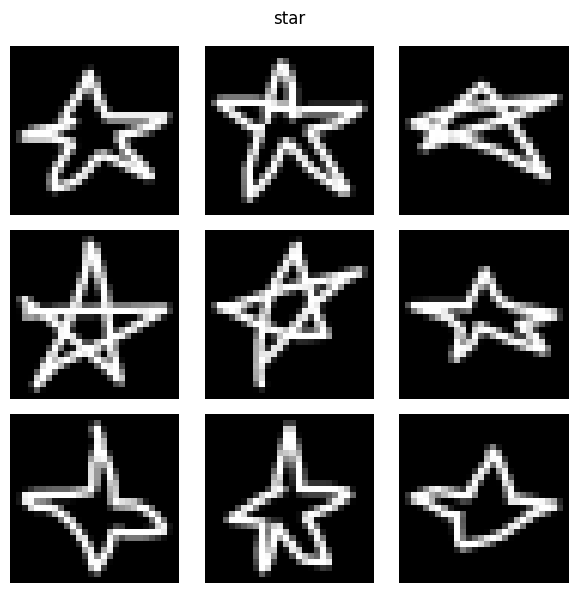

In [ ]:
# Checking the data
import numpy as np
import matplotlib.pyplot as plt

# Example class
class_name = "star"
data = np.load(f"{QUICKDRAW_NPY_DIR}/{class_name}.npy")

import random

num_samples = 9
indices = random.sample(range(len(data)), num_samples)

plt.figure(figsize=(6,6))

for i, idx in enumerate(indices):
    plt.subplot(3,3,i+1)
    img = data[idx].reshape(28,28)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.suptitle(class_name)
plt.tight_layout()
plt.show()

In [ ]:
# # Also save to goolge drive
# copy_item_to_drive(DATA_DIR)

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class QuickDrawNPYDataset(Dataset):
    """
    Load grayscale sketches from QuickDraw numpy_bitmaps.

    Convention: there are multiple .npy files under QUICKDRAW_NPY_DIR,
    each corresponding to a class, with filenames like 'cat.npy', 'airplane.npy'.
    Each .npy typically has shape [N, 784] or [N, 28, 28], with values in [0, 255].

    The original data is 28×28; it will be resized to 32×32 in the transform before being fed into the model.
    """

    def __init__(
        self,
        root: str,
        max_items_per_class: int = MAX_ITEMS_PER_CLASS,
        train: bool = True,
        transform=None,
    ):
        super().__init__()
        self.root = root
        self.transform = transform

        all_files = sorted(
            [f for f in os.listdir(root) if f.endswith(".npy")]
        )
        if len(all_files) == 0:
            raise RuntimeError(
                f"No .npy files found in {root}. "
                "Download QuickDraw numpy_bitmaps please"
            )

        # Use only the first NUM_QD_CLASSES files to avoid the full set of 345 classes being too large.
        selected_files = all_files[:NUM_QD_CLASSES]
        print("[QuickDraw] Using classes:")
        for i, fname in enumerate(selected_files):
            print(f"  class {i}: {fname}")

        self.class_names = selected_files
        self.images = []
        self.labels = []

        for class_idx, fname in enumerate(selected_files):
            path = os.path.join(root, fname)
            arr = np.load(path)  # [N, 784] or [N, 28, 28]

            if max_items_per_class is not None and arr.shape[0] > max_items_per_class:
                arr = arr[:max_items_per_class]

            n_total = arr.shape[0]
            n_train = int(n_total * 0.9)
            if train:
                arr = arr[:n_train]
            else:
                arr = arr[n_train:]

            if arr.ndim == 2:
                arr = arr.reshape(-1, 28, 28)

            for img in arr:
                self.images.append(img.astype(np.uint8))
                self.labels.append(class_idx)

        self.images = np.stack(self.images, axis=0)  # [N, 28,28]
        self.labels = np.array(self.labels, dtype=np.int64)
        print(f"[QuickDraw] Loaded {len(self.images)} images, "
              f"{len(self.class_names)} classes. train={train}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # [28,28], uint8
        label = int(self.labels[idx])

        img = torch.from_numpy(img).float().unsqueeze(0)  # [1,28,28]

        if self.transform is not None:
            img = self.transform(img)  # [1,32,32] then [-1,1]

        return img, label


def get_quickdraw_dataloader(
    batch_size: int,
    num_workers: int = 2,
    train: bool = True,
):
    transform = transforms.Compose(
        [
            transforms.Resize((32, 32)),
            transforms.Lambda(lambda x: x / 127.5 - 1.0),  # [0,255] → [-1,1]
        ]
    )

    dataset = QuickDrawNPYDataset(
        root=QUICKDRAW_NPY_DIR,
        max_items_per_class=MAX_ITEMS_PER_CLASS,
        train=train,
        transform=transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=train,
        num_workers=num_workers,
        pin_memory=True,
    )
    return loader

In [ ]:
# UNet backbone for 32x32 CIFAR-10 (fixed skip connections)

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPosEmb(nn.Module):
    """Standard sin-cos time embedding."""
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        device = timesteps.device
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        freqs = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups: int = 8, dropout: float = 0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch),
        )

        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)

        self.skip = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act(h)

        t = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + t

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)
        h = self.dropout(h)

        return h + self.skip(x)


class AttnBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.q = nn.Conv2d(channels, channels, kernel_size=1)
        self.k = nn.Conv2d(channels, channels, kernel_size=1)
        self.v = nn.Conv2d(channels, channels, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        h_in = x

        x = self.norm(x)
        q = self.q(x).reshape(B, C, H * W).permute(0, 2, 1)   # (B, HW, C)
        k = self.k(x).reshape(B, C, H * W)                    # (B, C, HW)
        v = self.v(x).reshape(B, C, H * W).permute(0, 2, 1)   # (B, HW, C)

        attn = torch.bmm(q, k) / math.sqrt(C)                 # (B, HW, HW)
        attn = F.softmax(attn, dim=-1)
        out = torch.bmm(attn, v)                              # (B, HW, C)
        out = out.permute(0, 2, 1).reshape(B, C, H, W)
        out = self.proj(out)

        return h_in + out


class Downsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class UNetModel(nn.Module):
    """
    UNet for 32x32 images, with:
      - Sinusoidal time embedding
      - Optional class-conditional embedding
    """

    def __init__(
        self,
        in_ch: int = 3,
        base_ch: int = 64,
        ch_mult=(1, 2, 4, 4),
        time_emb_dim: int = 256,
        dropout: float = 0.0,
        num_classes: int = None,
    ):
        super().__init__()

        # time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim),
        )

        # class embedding
        self.num_classes = num_classes
        if num_classes is not None:
            self.label_emb = nn.Embedding(num_classes, time_emb_dim)

        # input conv
        self.in_conv = nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1)

        # ----- Down path -----
        down_channels = [base_ch * m for m in ch_mult]
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        ch = base_ch
        for i, ch_out in enumerate(down_channels):
            self.down_blocks.append(
                nn.ModuleList(
                    [
                        ResBlock(ch, ch_out, time_emb_dim, dropout=dropout),
                        ResBlock(ch_out, ch_out, time_emb_dim, dropout=dropout),
                        AttnBlock(ch_out),
                    ]
                )
            )
            ch = ch_out

            if i != len(down_channels) - 1:
                self.downsamples.append(Downsample(ch))

        # ----- Middle -----
        self.mid_block1 = ResBlock(ch, ch, time_emb_dim, dropout=dropout)
        self.mid_attn = AttnBlock(ch)
        self.mid_block2 = ResBlock(ch, ch, time_emb_dim, dropout=dropout)

        # ----- Up path -----
        self.up_blocks = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        for i, ch_out in reversed(list(enumerate(down_channels))):
            self.up_blocks.append(
                nn.ModuleList(
                    [
                        ResBlock(ch + ch_out, ch_out, time_emb_dim, dropout=dropout),
                        ResBlock(ch_out, ch_out, time_emb_dim, dropout=dropout),
                        AttnBlock(ch_out),
                    ]
                )
            )
            ch = ch_out
            if i != 0:
                self.upsamples.append(Upsample(ch))

        self.out_norm = nn.GroupNorm(8, ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(ch, in_ch, kernel_size=3, padding=1)

    def forward(self, x, t, y=None):
        if t.dim() == 0:
            t = t[None]

        # time embedding
        t_emb = self.time_mlp(t)  # [B, time_emb_dim]

        # class embedding
        if self.num_classes is not None and y is not None:
            if y.dim() == 0:
                y = y[None]
            y_emb = self.label_emb(y.to(t_emb.device))  # [B, time_emb_dim]
            t_emb = t_emb + y_emb

        # input conv
        h = self.in_conv(x)
        hs = [h]

        # Down
        for i, (res1, res2, attn) in enumerate(self.down_blocks):
            h = res1(h, t_emb)
            h = res2(h, t_emb)
            if attn is not None:
                h = attn(h)
            hs.append(h)
            if i != len(self.down_blocks) - 1:
                h = self.downsamples[i](h)

        # Middle
        h = self.mid_block1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)

        # Up
        for i, (res1, res2, attn) in enumerate(self.up_blocks):
            skip = hs.pop()

            h = torch.cat([h, skip], dim=1)
            h = res1(h, t_emb)
            h = res2(h, t_emb)
            if attn is not None:
                h = attn(h)
            if i != len(self.up_blocks) - 1:
                h = self.upsamples[i](h)

        h = self.out_norm(h)
        h = self.out_act(h)
        return self.out_conv(h)


## Teacher

In [ ]:
class GaussianDiffusion(nn.Module):

    def __init__(
        self,
        model: nn.Module,
        image_size: int = 32,
        channels: int = 3,
        timesteps: int = 1000,
        beta_start: float = 1e-4,
        beta_end: float = 0.02,
        device: torch.device = DEVICE,
    ):
        super().__init__()
        self.model = model
        self.image_size = image_size
        self.channels = channels
        self.timesteps = timesteps
        self.device = device

        betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", alphas_cumprod)
        self.register_buffer("sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod))
        self.register_buffer("sqrt_one_minus_alphas_cumprod", torch.sqrt(1.0 - alphas_cumprod))

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

    @torch.no_grad()
    def p_sample(self, x_t, t, y=None):
        betas_t = self.betas[t].view(-1, 1, 1, 1)
        alphas_t = self.alphas[t].view(-1, 1, 1, 1)
        alphas_cumprod_t = self.alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_recip_alphas_t = torch.sqrt(1.0 / alphas_t)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

        # εθ(x_t, t, y)
        eps_theta = self.model(x_t, t, y)

        # predict x0
        x0_pred = (x_t - sqrt_one_minus_alphas_cumprod_t * eps_theta) / torch.sqrt(alphas_cumprod_t)

        mean = sqrt_recip_alphas_t * (x_t - betas_t / sqrt_one_minus_alphas_cumprod_t * eps_theta)

        noise = torch.randn_like(x_t)
        nonzero_mask = (t != 0).float().view(-1, 1, 1, 1)
        return mean + nonzero_mask * torch.sqrt(betas_t) * noise

    @torch.no_grad()
    def sample(self, batch_size: int, device: torch.device = DEVICE, y: torch.Tensor = None):
        self.eval()
        x = torch.randn(batch_size, self.channels, self.image_size, self.image_size, device=device)
        if y is not None and y.dim() == 0:
            y = y.repeat(batch_size)

        for t in reversed(range(self.timesteps)):
            t_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)
            x = self.p_sample(x, t_batch, y)
        return x

    def forward(self, x_start: torch.Tensor, y: torch.Tensor = None) -> torch.Tensor:
        b = x_start.size(0)
        device = x_start.device
        t = torch.randint(0, self.timesteps, (b,), device=device, dtype=torch.long)
        noise = torch.randn_like(x_start)
        x_t = self.q_sample(x_start, t, noise)
        eps_pred = self.model(x_t, t, y)
        return F.mse_loss(eps_pred, noise)

In [ ]:
def load_teacher(
    ckpt_path: str | None = None,
    device: torch.device = DEVICE,
):

    if ckpt_path is None:
        latest_path = os.path.join(TEACHER_CKPT_DIR, "teacher_latest.pt")
        legacy_path = os.path.join(TEACHER_CKPT_DIR, "teacher_diffusion.pt")

        if os.path.exists(latest_path):
            ckpt_path = latest_path
        elif os.path.exists(legacy_path):
            ckpt_path = legacy_path
        else:
            raise FileNotFoundError(
                f"No teacher checkpoint found in {TEACHER_CKPT_DIR} "
                f"(tried {latest_path} and {legacy_path})"
            )

    ckpt = torch.load(ckpt_path, map_location=device)
    config = ckpt.get("config", {})

    base_ch     = config.get("base_ch", 64)
    time_emb_dim = config.get("time_emb_dim", 256)
    dropout     = config.get("dropout", 0.0)
    timesteps   = config.get("timesteps", 1000)
    beta_start  = config.get("beta_start", 1e-4)
    beta_end    = config.get("beta_end", 2e-2)
    num_classes = config.get("num_classes", NUM_QD_CLASSES)

    unet = UNetModel(
        in_ch=1,
        base_ch=base_ch,
        ch_mult=(1, 2, 2, 2),
        time_emb_dim=time_emb_dim,
        dropout=dropout,
        num_classes=num_classes,
    ).to(device)

    diffusion = GaussianDiffusion(
        model=unet,
        image_size=32,
        channels=1,
        timesteps=timesteps,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    ).to(device)

    # Load weights
    if "unet" in ckpt:
        unet.load_state_dict(ckpt["unet"])
    else:
        raise KeyError("Teacher ckpt is missing 'unet' state_dict")

    if "diffusion" in ckpt:
        diffusion.load_state_dict(ckpt["diffusion"])

    diffusion.eval()
    print(f"[Teacher] Loaded checkpoint from {ckpt_path}")
    return diffusion

In [ ]:
@torch.no_grad()
def generate_samples_teacher(
    diffusion: GaussianDiffusion,
    out_dir: str,
    num_samples: int,
    batch_size: int = EVAL_BATCH_SIZE,
    device: torch.device = DEVICE,
    class_id: int | None = None,
):
    os.makedirs(out_dir, exist_ok=True)
    diffusion.eval()
    count = 0
    n_batches = math.ceil(num_samples / batch_size)

    if device.type == "cuda":
        torch.cuda.synchronize()

    t0 = perf_counter()
    with torch.no_grad():
        for i in range(n_batches):
            current_bs = min(batch_size, num_samples - count)

            # Generate Label vectors
            if class_id is None:
                y = torch.randint(0, NUM_QD_CLASSES, (current_bs,), device=device)
            else:
                y = torch.full((current_bs,), int(class_id), device=device, dtype=torch.long)

            imgs = diffusion.sample(current_bs, device=device, y=y)
            imgs = (imgs.clamp(-1, 1) + 1) / 2.0  # [-1,1] → [0,1]

            for j in range(current_bs):
                save_path = os.path.join(out_dir, f"{count + j:06d}.png")
                # save_image(imgs[j], save_path)

                img = (imgs[j] * 0.5 + 0.5).clamp(0, 1)
                save_image(img, save_path)

            count += current_bs
            print(f"[Teacher] [{i+1}/{n_batches}] Generated {count}/{num_samples} images")

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - t0
    print(f"[Teacher] Total sampling time for {num_samples} images: {elapsed:.2f} s")
    print(f"[Teacher] Time per 1000 images: {elapsed / (num_samples / 1000):.2f} s")
    print(f"[Teacher] NFE per sample: {diffusion.timesteps}")
    return elapsed

In [ ]:
def train_teacher(
    data_dir: str = DATA_DIR,
    out_dir: str = TEACHER_CKPT_DIR,
    epochs: int = EPOCHS_TEACHER,
    batch_size: int = 128,
    lr: float = 2e-4,
    base_ch: int = 64,
    time_emb_dim: int = 256,
    dropout: float = 0.0,
    timesteps: int = 1000,
    beta_start: float = 1e-4,
    beta_end: float = 2e-2,
    log_interval: int = 100,
    seed: int = 42,
    save_every: int = 5,
):
    set_seed(seed)
    device = DEVICE

    global TEACHER_LOSS_HISTORY
    TEACHER_LOSS_HISTORY = []

    unet = UNetModel(
        in_ch=1,
        base_ch=base_ch,
        ch_mult=(1, 2, 2, 2),
        # num_res_blocks=2,
        time_emb_dim=time_emb_dim,
        num_classes=NUM_QD_CLASSES,
        dropout=dropout,
        # attn_resolutions=(16,),
        # image_size=32,
    ).to(device)

#         in_ch=1,
#         base_ch=base_ch,
#         ch_mult=(1, 2, 4, 4),
#         time_emb_dim=time_emb_dim,
#         dropout=dropout,
#         num_classes=num_classes,

    diffusion = GaussianDiffusion(
        model=unet,
        image_size=32,
        channels=1,
        timesteps=timesteps,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    ).to(device)

    dataloader = get_quickdraw_dataloader(batch_size, train=True)
    steps_per_epoch = len(dataloader)

    optimizer = optim.Adam(diffusion.parameters(), lr=lr)

    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = os.path.join(out_dir, "teacher_latest.pt")


    start_epoch = 0
    global_step = 0

    if os.path.exists(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location=device)
            if "unet" in ckpt:
                unet.load_state_dict(ckpt["unet"])
            if "diffusion" in ckpt:
                diffusion.load_state_dict(ckpt["diffusion"])
            if "optimizer" in ckpt:
                optimizer.load_state_dict(ckpt["optimizer"])
            start_epoch = ckpt.get("epoch", 0)
            global_step = start_epoch * steps_per_epoch
            print(f"[Teacher] Resuming from epoch {start_epoch}/{epochs}")
        except Exception as e:
            print("[Teacher] Failed to load existing checkpoint, start from scratch:", e)
            start_epoch = 0
            global_step = 0


    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs * steps_per_epoch,
        last_epoch=global_step - 1,
    )

    if start_epoch >= epochs:
        print(f"[Teacher] Already reached epoch {start_epoch}, nothing to do.")
        return ckpt_path

    # Begin Training
    for epoch in range(start_epoch, epochs):
        diffusion.train()
        epoch_loss = 0.0
        t0 = time()

        for batch_idx, (x, y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)

            loss = diffusion(x, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(diffusion.parameters(), max_norm=1.0)
            optimizer.step()
            lr_scheduler.step()

            global_step += 1
            epoch_loss += loss.item()

            if (batch_idx + 1) % log_interval == 0:
                print(
                    f"[Teacher][Epoch {epoch+1}/{epochs}] "
                    f"Step {batch_idx+1}/{len(dataloader)}, "
                    f"Loss: {loss.item():.4f}"
                )

        epoch_loss /= len(dataloader)
        dt = time() - t0
        print(
            f"[Teacher] Epoch {epoch+1}/{epochs} finished. "
            f"avg loss={epoch_loss:.4f}, time={dt:.1f}s"
        )
        TEACHER_LOSS_HISTORY.append(epoch_loss)

        # Save to goolge drive
        if ((epoch + 1) % save_every == 0) or (epoch + 1 == epochs):
            torch.save(
                {
                    "unet": unet.state_dict(),
                    "diffusion": diffusion.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "epoch": epoch + 1,
                },
                ckpt_path,
            )
            print(f"[Teacher] Saved checkpoint to {ckpt_path}")
            copy_item_to_drive(out_dir)

    print(f"[Teacher] Training done. Latest checkpoint at {ckpt_path}")
    return ckpt_path

In [ ]:
train_teacher()

# # Copy checkpoints
# copy_item_to_drive(TEACHER_CKPT_DIR)


[QuickDraw] Using classes:
  class 0: airplane.npy
  class 1: apple.npy
  class 2: bicycle.npy
  class 3: bird.npy
  class 4: book.npy
  class 5: car.npy
  class 6: cat.npy
  class 7: chair.npy
  class 8: clock.npy
[QuickDraw] Loaded 81000 images, 9 classes. train=True
[Teacher][Epoch 1/80] Step 100/633, Loss: 0.0607
[Teacher][Epoch 1/80] Step 200/633, Loss: 0.0352
[Teacher][Epoch 1/80] Step 300/633, Loss: 0.0402
[Teacher][Epoch 1/80] Step 400/633, Loss: 0.0323
[Teacher][Epoch 1/80] Step 500/633, Loss: 0.0313
[Teacher][Epoch 1/80] Step 600/633, Loss: 0.0333
[Teacher] Epoch 1/80 finished. avg loss=0.0550, time=48.3s
[Teacher][Epoch 2/80] Step 100/633, Loss: 0.0358
[Teacher][Epoch 2/80] Step 200/633, Loss: 0.0294
[Teacher][Epoch 2/80] Step 300/633, Loss: 0.0331
[Teacher][Epoch 2/80] Step 400/633, Loss: 0.0321
[Teacher][Epoch 2/80] Step 500/633, Loss: 0.0300
[Teacher][Epoch 2/80] Step 600/633, Loss: 0.0317
[Teacher] Epoch 2/80 finished. avg loss=0.0315, time=45.8s
[Teacher][Epoch 3/80] St

'/content/FastFlowDiff_QuickDraw/teacher_ckpt/teacher_latest.pt'

## Consistency Model

In [ ]:
class ConsistencyModel(nn.Module):
    """
    Consistency-style model on top of a UNet that predicts x0 from (x_t, t, y).

    - underlying UNet: x0_theta = unet(x_t, t, y)
    - training: MSE to x0 + consistency regularization across times
    - sampling: 4-step sampler T -> 3/4 T -> 1/2 T -> 1/4 T -> 0
    """

    def __init__(
        self,
        unet: UNetModel,
        timesteps: int = 1000,
        beta_start: float = 1e-4,
        beta_end: float = 2e-2,
        device: torch.device = DEVICE,
    ):
        super().__init__()
        self.unet = unet
        self.timesteps = timesteps
        self.device = device

        # diffusion-style noise schedule (only used for q_sample / transitions)
        betas = torch.linspace(beta_start, beta_end, timesteps, dtype=torch.float64)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer("betas", betas.float())
        self.register_buffer("alphas_cumprod", alphas_cumprod.float())
        self.register_buffer(
            "sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod).float()
        )
        self.register_buffer(
            "sqrt_one_minus_alphas_cumprod",
            torch.sqrt(1.0 - alphas_cumprod).float(),
        )

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        """
        Forward noising: q(x_t | x0, t).
        """
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_om = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_ac * x0 + sqrt_om * noise

    def forward(self, x_t: torch.Tensor, t: torch.Tensor, y: torch.Tensor | None = None) -> torch.Tensor:
        """
        Predict x0 from (x_t, t, y) using the underlying UNet.
        """
        return self.unet(x_t, t, y)

    def training_loss(
        self,
        x0: torch.Tensor,
        y: torch.Tensor,
        lambda_consistency: float = 0.1,
    ) -> torch.Tensor:

        b = x0.size(0)
        device = x0.device

        # t1 in [0.5T, T), t2 in [1, 0.5T)
        t1 = torch.randint(
            int(self.timesteps * 0.5),
            self.timesteps,
            (b,),
            device=device,
            dtype=torch.long,
        )
        t2 = torch.randint(
            1,
            int(self.timesteps * 0.5),
            (b,),
            device=device,
            dtype=torch.long,
        )
        # Make sure t1 >= t2
        t1, t2 = torch.max(t1, t2), torch.min(t1, t2)

        noise1 = torch.randn_like(x0)
        noise2 = torch.randn_like(x0)
        x_t1 = self.q_sample(x0, t1, noise1)
        x_t2 = self.q_sample(x0, t2, noise2)

        x0_pred_1 = self.forward(x_t1, t1, y)
        x0_pred_2 = self.forward(x_t2, t2, y)

        loss_x0 = F.mse_loss(x0_pred_1, x0) + F.mse_loss(x0_pred_2, x0)
        loss_cons = F.mse_loss(x0_pred_1, x0_pred_2)
        loss = loss_x0 + lambda_consistency * loss_cons
        return loss

    def transition_x_t_to_tprime(
        self,
        x_t: torch.Tensor,
        x0_pred: torch.Tensor,
        t: torch.Tensor,
        t_prime: torch.Tensor,
    ) -> torch.Tensor:
        """
        Given x_t and predicted x0, move to x_{t'} using DDIM-style reparameterization.
        """
        sqrt_ac_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_om_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        eps_est = (x_t - sqrt_ac_t * x0_pred) / (sqrt_om_t + 1e-8)

        sqrt_ac_tp = self.sqrt_alphas_cumprod[t_prime].view(-1, 1, 1, 1)
        sqrt_om_tp = self.sqrt_one_minus_alphas_cumprod[t_prime].view(-1, 1, 1, 1)
        x_tprime = sqrt_ac_tp * x0_pred + sqrt_om_tp * eps_est
        return x_tprime

    @torch.no_grad()
    def sample_4step(
        self,
        batch_size: int,
        device: torch.device = DEVICE,
        y: torch.Tensor | None = None,
        t_T: int | None = None,
    ) -> torch.Tensor:
        """
        4-step sampler:
          T -> 3/4 T -> 1/2 T -> 1/4 T -> 0
        """
        self.eval()
        device = device or self.device

        if t_T is None:
            t_T = self.timesteps - 1

        t3 = int(self.timesteps * 0.75)
        t2 = int(self.timesteps * 0.50)
        t1 = int(self.timesteps * 0.25)

        t_T_tensor = torch.full((batch_size,), t_T, device=device, dtype=torch.long)
        t3_tensor = torch.full((batch_size,), t3, device=device, dtype=torch.long)
        t2_tensor = torch.full((batch_size,), t2, device=device, dtype=torch.long)
        t1_tensor = torch.full((batch_size,), t1, device=device, dtype=torch.long)
        t0_tensor = torch.zeros(batch_size, device=device, dtype=torch.long)

        if y is not None and y.dim() == 0:
            y = y.repeat(batch_size)
        if y is not None:
            y = y.to(device)

        # 1. Start from x_T
        x_T = torch.randn(batch_size, 1, 32, 32, device=device)

        # 2. T -> 3/4 T
        x0_pred_T = self.forward(x_T, t_T_tensor, y)
        x_3 = self.transition_x_t_to_tprime(x_T, x0_pred_T, t_T_tensor, t3_tensor)

        # 3. 3/4 T -> 1/2 T
        x0_pred_3 = self.forward(x_3, t3_tensor, y)
        x_2 = self.transition_x_t_to_tprime(x_3, x0_pred_3, t3_tensor, t2_tensor)

        # 4. 1/2 T -> 1/4 T
        x0_pred_2 = self.forward(x_2, t2_tensor, y)
        x_1 = self.transition_x_t_to_tprime(x_2, x0_pred_2, t2_tensor, t1_tensor)

        # 5. 1/4 T -> 0
        x0_pred_1 = self.forward(x_1, t1_tensor, y)
        x_0 = self.transition_x_t_to_tprime(x_1, x0_pred_1, t1_tensor, t0_tensor)

        return x_0.clamp(-1.0, 1.0)




In [ ]:
def train_consistency_4step(
    data_dir: str = DATA_DIR,
    out_dir: str = CONSIST_CKPT_DIR,
    epochs: int = EPOCHS_CONSIST,
    batch_size: int = 128,
    lr: float = 2e-4,
    base_ch: int = 64,
    time_emb_dim: int = 256,
    dropout: float = 0.0,
    timesteps: int = 1000,
    beta_start: float = 1e-4,
    beta_end: float = 2e-2,
    lambda_consistency: float = 0.1,
    log_interval: int = 100,
    seed: int = 123,
    init_from_teacher: bool = True,
    teacher_ckpt_path: str | None = None,
    save_every: int = 5,
):
    set_seed(seed)
    device = DEVICE

    global CONSIST4_LOSS_HISTORY
    CONSIST4_LOSS_HISTORY = []

    student_unet = UNetModel(
        in_ch=1,
        base_ch=base_ch,
        ch_mult=(1, 2, 2, 2),
        time_emb_dim=time_emb_dim,
        num_classes=NUM_QD_CLASSES,
        dropout=dropout,
    ).to(device)

    student = ConsistencyModel(
        unet=student_unet,
        timesteps=timesteps,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    ).to(device)

    # Initialize from the teacher checkpoint.
    if init_from_teacher and teacher_ckpt_path is not None and os.path.exists(teacher_ckpt_path):
        ckpt_teacher = torch.load(teacher_ckpt_path, map_location=device)
        if "unet" in ckpt_teacher:
            try:
                student_unet.load_state_dict(ckpt_teacher["unet"], strict=False)
                print("[Consist-4] Loaded teacher UNet weights as initialization.")
            except Exception as e:
                print("[Consist-4] Failed to load teacher UNet:", e)

    dataloader = get_quickdraw_dataloader(batch_size, train=True)
    steps_per_epoch = len(dataloader)

    optimizer = optim.Adam(student.parameters(), lr=lr)

    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = os.path.join(out_dir, "consistency_4step_latest.pt")  # ⭐

    # Recover from check point
    start_epoch = 0
    global_step = 0

    if os.path.exists(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location=device)
            if "student_unet" in ckpt:
                student_unet.load_state_dict(ckpt["student_unet"])
            if "consistency_model" in ckpt:
                student.load_state_dict(ckpt["consistency_model"])
            if "optimizer" in ckpt:
                optimizer.load_state_dict(ckpt["optimizer"])
            start_epoch = ckpt.get("epoch", 0)
            global_step = ckpt.get("step", start_epoch * steps_per_epoch)
            print(f"[Consist-4] Resuming from epoch {start_epoch}/{epochs}")
        except Exception as e:
            print("[Consist-4] Failed to load existing checkpoint, start from scratch:", e)
            start_epoch = 0
            global_step = 0

    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs * steps_per_epoch,
        last_epoch=global_step - 1,
    )

    if start_epoch >= epochs:
        print(f"[Consist-4] Already reached epoch {start_epoch}, nothing to do.")
        return ckpt_path

    # Begin Training
    student.train()
    for epoch in range(start_epoch + 1, epochs + 1):
        epoch_loss = 0.0
        t0 = time()

        for batch_idx, (x, y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)

            loss = student.training_loss(
                x0=x,
                y=y,
                lambda_consistency=lambda_consistency,
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
            optimizer.step()
            lr_scheduler.step()

            global_step += 1
            epoch_loss += loss.item()

            if (batch_idx + 1) % log_interval == 0:
                print(
                    f"[Consist-4][Epoch {epoch}/{epochs}] "
                    f"Step {batch_idx+1}/{len(dataloader)}, "
                    f"Loss: {loss.item():.4f}"
                )

        epoch_loss /= len(dataloader)
        elapsed = time() - t0
        print(
            f"[Consist-4] Epoch {epoch}/{epochs} done. "
            f"Avg loss={epoch_loss:.4f}, time={elapsed:.1f}s"
        )
        CONSIST4_LOSS_HISTORY.append(epoch_loss)

        # Save
        if (epoch % save_every == 0) or (epoch == epochs):
            torch.save(
                {
                    "student_unet": student_unet.state_dict(),
                    "consistency_model": student.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "epoch": epoch,
                    "step": global_step,
                    "config": {
                        "base_ch": base_ch,
                        "time_emb_dim": time_emb_dim,
                        "dropout": dropout,
                        "timesteps": timesteps,
                        "beta_start": beta_start,
                        "beta_end": beta_end,
                        "num_classes": NUM_QD_CLASSES,
                    },
                },
                ckpt_path,
            )
            print(f"[Consist-4] Saved checkpoint to {ckpt_path}")
            copy_item_to_drive(out_dir)

    print(f"[Consist-4] Training finished. Latest checkpoint saved to {ckpt_path}")
    return ckpt_path

In [ ]:
def load_consistency_4step(
    ckpt_path: str | None = None,
    device: torch.device = DEVICE,
) -> ConsistencyModel:

    if ckpt_path is None:
        latest_path = os.path.join(CONSIST_CKPT_DIR, "consistency_4step_latest.pt")
        legacy_path = os.path.join(CONSIST_CKPT_DIR, "consistency_4step.pt")

        if os.path.exists(latest_path):
            ckpt_path = latest_path
        elif os.path.exists(legacy_path):
            ckpt_path = legacy_path
        else:
            raise FileNotFoundError(
                f"No consistency checkpoint found in {CONSIST_CKPT_DIR} "
                f"(tried {latest_path} and {legacy_path})"
            )

    ckpt = torch.load(ckpt_path, map_location=device)
    config = ckpt.get("config", {})

    base_ch      = config.get("base_ch", 64)
    time_emb_dim = config.get("time_emb_dim", 256)
    dropout      = config.get("dropout", 0.0)
    timesteps    = config.get("timesteps", 1000)
    beta_start   = config.get("beta_start", 1e-4)
    beta_end     = config.get("beta_end", 2e-2)
    num_classes  = config.get("num_classes", NUM_QD_CLASSES)

    student_unet = UNetModel(
        in_ch=1,
        base_ch=base_ch,
        ch_mult=(1, 2, 2, 2),
        time_emb_dim=time_emb_dim,
        dropout=dropout,
        num_classes=num_classes,
    ).to(device)

    student = ConsistencyModel(
        student_unet,
        timesteps=timesteps,
        beta_start=beta_start,
        beta_end=beta_end,
        device=device,
    ).to(device)

    # Load Weights
    if "student_unet" in ckpt:
        student_unet.load_state_dict(ckpt["student_unet"])
    else:
        raise KeyError("Consistency ckpt missing 'student_unet'")

    if "consistency_model" in ckpt:
        student.load_state_dict(ckpt["consistency_model"])

    student.eval()
    print(f"[Consist-4] Loaded checkpoint from {ckpt_path}")
    return student


@torch.no_grad()
def generate_samples_consistency_4step(
    student: ConsistencyModel,
    out_dir: str,
    num_samples: int,
    batch_size: int = EVAL_BATCH_SIZE,
    device: torch.device = DEVICE,
    class_id: int | None = None,
):
    os.makedirs(out_dir, exist_ok=True)
    student.eval()
    count = 0
    n_batches = math.ceil(num_samples / batch_size)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = perf_counter()

    with torch.no_grad():
        for i in range(n_batches):
            current_bs = min(batch_size, num_samples - count)

            if class_id is None:
                y = torch.randint(0, NUM_QD_CLASSES, (current_bs,), device=device)
            else:
                y = torch.full((current_bs,), int(class_id), device=device, dtype=torch.long)

            imgs = student.sample_4step(current_bs, device=device, y=y)
            imgs = (imgs.clamp(-1, 1) + 1) / 2.0  # [-1,1] -> [0,1]

            for j in range(current_bs):
                save_path = os.path.join(out_dir, f"{count + j:06d}.png")
                # save_image(imgs[j], save_path)

                img = (imgs[j] * 0.5 + 0.5).clamp(0, 1)
                save_image(img, save_path)

            count += current_bs
            print(
                f"[Consistency-4] [{i+1}/{n_batches}] Generated {count}/{num_samples} images"
            )

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - t0
    print(
        f"[Consistency-4] Total sampling time for {num_samples} images: {elapsed:.2f} s"
    )
    print(
        f"[Consistency-4] Time per 1000 images: {elapsed / (num_samples / 1000):.2f} s"
    )
    print(f"[Consistency-4] NFE per sample: 4")
    return elapsed

In [ ]:
train_consistency_4step(init_from_teacher=True)

# # Copy checkpoints
# copy_item_to_drive(CONSIST_CKPT_DIR)


[QuickDraw] Using classes:
  class 0: airplane.npy
  class 1: apple.npy
  class 2: bicycle.npy
  class 3: bird.npy
  class 4: book.npy
  class 5: car.npy
  class 6: cat.npy
  class 7: chair.npy
  class 8: clock.npy
[QuickDraw] Loaded 81000 images, 9 classes. train=True
[Consist-4][Epoch 1/80] Step 100/633, Loss: 0.3429
[Consist-4][Epoch 1/80] Step 200/633, Loss: 0.3208
[Consist-4][Epoch 1/80] Step 300/633, Loss: 0.3174
[Consist-4][Epoch 1/80] Step 400/633, Loss: 0.3037
[Consist-4][Epoch 1/80] Step 500/633, Loss: 0.2991
[Consist-4][Epoch 1/80] Step 600/633, Loss: 0.3029
[Consist-4] Epoch 1/80 done. Avg loss=0.3333, time=89.7s
[Consist-4][Epoch 2/80] Step 100/633, Loss: 0.3255
[Consist-4][Epoch 2/80] Step 200/633, Loss: 0.2976
[Consist-4][Epoch 2/80] Step 300/633, Loss: 0.3143
[Consist-4][Epoch 2/80] Step 400/633, Loss: 0.2915
[Consist-4][Epoch 2/80] Step 500/633, Loss: 0.3236
[Consist-4][Epoch 2/80] Step 600/633, Loss: 0.2924
[Consist-4] Epoch 2/80 done. Avg loss=0.3078, time=89.4s
[Con

'/content/FastFlowDiff_QuickDraw/consistency_ckpt/consistency_4step_latest.pt'

## Flow Matching / Rectified Flow

In [ ]:
class FlowMatchingModel(nn.Module):
    """
    Simple Rectified-Flow-style model with straight-line paths:
      x_t = (1 - t) * x0 + t * x1,  with x0 ~ N(0, I), x1 ~ data
      v*(x_t, t) = x1 - x0

    The UNet predicts v_theta(x_t, t, y), and we minimize MSE to v*.

    Sampling:
      Solve dx/dt = v_theta(x, t, y) from t=0 to t=1 with Euler steps,
      starting from x0 ~ N(0, I).

    This version is:
      - 1-channel (QuickDraw bitmap, 32x32)
      - class-conditional via label y
    """

    def __init__(
        self,
        unet: UNetModel,
        time_emb_steps: int = 1000,
        device: torch.device = DEVICE,
    ):
        super().__init__()
        self.unet = unet
        self.time_emb_steps = time_emb_steps
        self.device = device

    def forward(self, x_t: torch.Tensor, t_continuous: torch.Tensor, y: torch.Tensor = None):
        """
        x_t: [B,1,32,32]
        t_continuous: [B] in [0,1]
        y: [B] class indices or None
        """
        if t_continuous.dim() == 0:
            t_continuous = t_continuous[None]

        t_idx = (t_continuous.clamp(0.0, 1.0) * (self.time_emb_steps - 1)).long()
        return self.unet(x_t, t_idx, y)

    def training_loss(self, x1: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        x1: data sample ~ p_data, [B,1,32,32]
        y: corresponding class labels, [B]
        """
        b = x1.size(0)
        device = x1.device

        # base sample x0 ~ N(0, I)
        x0 = torch.randn_like(x1)

        # t ~ Uniform(0, 1)
        t = torch.rand(b, device=device)  # [B]
        t_view = t.view(b, 1, 1, 1)

        x_t = (1.0 - t_view) * x0 + t_view * x1

        v_star = x1 - x0

        v_pred = self.forward(x_t, t, y)
        loss = F.mse_loss(v_pred, v_star)
        return loss

    @torch.no_grad()
    def sample(
        self,
        batch_size: int,
        num_steps: int = 16,
        device: torch.device = DEVICE,
        y: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Euler integration:
          x_{k+1} = x_k + dt * v_theta(x_k, t_k, y)
        where t_k = k / num_steps, dt = 1/num_steps.
        """
        self.eval()
        device = device or self.device

        if y is not None and y.dim() == 0:
            y = y.repeat(batch_size)
        if y is not None:
            y = y.to(device)

        x = torch.randn(batch_size, 1, 32, 32, device=device)
        dt = 1.0 / num_steps

        for k in range(num_steps):
            t_k = torch.full((batch_size,), k * dt, device=device)
            v_pred = self.forward(x, t_k, y)
            x = x + dt * v_pred

        return x.clamp(-1.0, 1.0)





In [ ]:
def train_flow_matching(
    data_dir: str = DATA_DIR,
    out_dir: str = FLOW_CKPT_DIR,
    epochs: int = EPOCHS_FLOW,
    batch_size: int = 128,
    lr: float = 2e-4,
    base_ch: int = 64,
    time_emb_dim: int = 256,
    dropout: float = 0.0,
    time_emb_steps: int = 1000,
    log_interval: int = 100,
    seed: int = 321,
    save_every: int = 5,
):
    """
    Train rectified-flow / flow-matching model on QuickDraw bitmap, class-conditional.
    """
    set_seed(seed)
    device = DEVICE

    global FLOW_LOSS_HISTORY
    FLOW_LOSS_HISTORY = []


    flow_unet = UNetModel(
        in_ch=1,
        base_ch=base_ch,
        ch_mult=(1, 2, 2, 2),
        time_emb_dim=time_emb_dim,
        num_classes=NUM_QD_CLASSES,
        dropout=dropout,
    ).to(device)

    flow_model = FlowMatchingModel(
        flow_unet,
        time_emb_steps=time_emb_steps,
    ).to(device)

    dataloader = get_quickdraw_dataloader(batch_size, train=True)
    steps_per_epoch = len(dataloader)

    optimizer = optim.Adam(flow_model.parameters(), lr=lr)

    os.makedirs(out_dir, exist_ok=True)
    ckpt_path = os.path.join(out_dir, "flow_matching_latest.pt")

    # Recover from check point
    start_epoch = 0
    global_step = 0

    if os.path.exists(ckpt_path):
        try:
            ckpt = torch.load(ckpt_path, map_location=device)
            if "flow_unet" in ckpt:
                flow_unet.load_state_dict(ckpt["flow_unet"])
            if "flow_model" in ckpt:
                flow_model.load_state_dict(ckpt["flow_model"])
            if "optimizer" in ckpt:
                optimizer.load_state_dict(ckpt["optimizer"])
            start_epoch = ckpt.get("epoch", 0)
            global_step = ckpt.get("step", start_epoch * steps_per_epoch)
            print(f"[Flow] Resuming from epoch {start_epoch}/{epochs}")
        except Exception as e:
            print("[Flow] Failed to load existing checkpoint, start from scratch:", e)
            start_epoch = 0
            global_step = 0

    lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs * steps_per_epoch,
        last_epoch=global_step - 1,
    )

    if start_epoch >= epochs:
        print(f"[Flow] Already reached epoch {start_epoch}, nothing to do.")
        return ckpt_path

    # Begin Training
    for epoch in range(start_epoch + 1, epochs + 1):
        epoch_loss = 0.0
        t0 = time()

        for batch_idx, (x, y) in enumerate(dataloader):
            x = x.to(device)
            y = y.to(device)

            # data x0 from data, x1 from N(0,I) as target distribution (or reverse)
            loss = flow_model.training_loss(x1=x, y=y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(flow_model.parameters(), max_norm=1.0)
            optimizer.step()
            lr_scheduler.step()

            global_step += 1
            epoch_loss += loss.item()

            if (batch_idx + 1) % log_interval == 0:
                print(
                    f"[Flow][Epoch {epoch}/{epochs}] "
                    f"Step {batch_idx+1}/{len(dataloader)}, "
                    f"Loss: {loss.item():.4f}"
                )

        epoch_loss /= len(dataloader)
        elapsed = time() - t0
        print(
            f"[Flow] ==> Epoch {epoch} done. "
            f"Avg loss: {epoch_loss:.4f}, time: {elapsed:.1f}s"
        )
        FLOW_LOSS_HISTORY.append(epoch_loss)

        # Save
        if (epoch % save_every == 0) or (epoch == epochs):
            torch.save(
                {
                    "flow_unet": flow_unet.state_dict(),
                    "flow_model": flow_model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "epoch": epoch,
                    "step": global_step,
                    "config": {
                        "base_ch": base_ch,
                        "time_emb_dim": time_emb_dim,
                        "dropout": dropout,
                        "time_emb_steps": time_emb_steps,
                        "num_classes": NUM_QD_CLASSES,
                    },
                },
                ckpt_path,
            )
            print(f"[Flow] Saved checkpoint to {ckpt_path}")
            copy_item_to_drive(out_dir)

    print(f"[Flow] Training done. Latest checkpoint at {ckpt_path}")
    return ckpt_path

In [ ]:
# Sampling & benchmarking

@torch.no_grad()
def generate_samples_flow(
    flow_model: FlowMatchingModel,
    out_dir: str,
    num_samples: int,
    batch_size: int = EVAL_BATCH_SIZE,
    num_steps: int = 16,
    device: torch.device = DEVICE,
    class_id: int | None = None,
):
    """
    Generate num_samples images from a trained flow_model (QuickDraw, 1x32x32, class-conditional).

    """
    os.makedirs(out_dir, exist_ok=True)
    flow_model.eval()

    count = 0
    n_batches = math.ceil(num_samples / batch_size)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = perf_counter()

    with torch.no_grad():
        for i in range(n_batches):
            current_bs = min(batch_size, num_samples - count)

            # Label vector
            if class_id is None:
                y = torch.randint(0, NUM_QD_CLASSES, (current_bs,), device=device)
            else:
                y = torch.full(
                    (current_bs,),
                    int(class_id),
                    device=device,
                    dtype=torch.long,
                )

            imgs = flow_model.sample(
                current_bs,
                num_steps=num_steps,
                device=device,
                y=y,
            )
            imgs = (imgs.clamp(-1, 1) + 1) / 2.0  # [-1,1] → [0,1]

            for j in range(current_bs):
                save_path = os.path.join(out_dir, f"{count + j:06d}.png")
                # save_image(imgs[j], save_path)

                img = (imgs[j] * 0.5 + 0.5).clamp(0, 1)
                save_image(img, save_path)

            count += current_bs
            print(f"[Flow] [{i+1}/{n_batches}] Generated {count}/{num_samples} images")

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = perf_counter() - t0
    print(f"[Flow] Total sampling time for {num_samples} images: {elapsed:.2f} s")
    print(f"[Flow] Time per 1000 images: {elapsed / (num_samples / 1000):.2f} s")
    print(f"[Flow] NFE per sample: {num_steps}")
    return elapsed



def load_flow_matching(
    ckpt_path: str | None = None,
    device: torch.device = DEVICE,
) -> FlowMatchingModel:

    if ckpt_path is None:
        latest_path = os.path.join(FLOW_CKPT_DIR, "flow_matching_latest.pt")
        legacy_path = os.path.join(FLOW_CKPT_DIR, "flow_matching.pt")

        if os.path.exists(latest_path):
            ckpt_path = latest_path
        elif os.path.exists(legacy_path):
            ckpt_path = legacy_path
        else:
            raise FileNotFoundError(
                f"No flow checkpoint found in {FLOW_CKPT_DIR} "
                f"(tried {latest_path} and {legacy_path})"
            )

    ckpt = torch.load(ckpt_path, map_location=device)
    config = ckpt.get("config", {})

    base_ch       = config.get("base_ch", 64)
    time_emb_dim  = config.get("time_emb_dim", 256)
    dropout       = config.get("dropout", 0.0)
    time_emb_steps = config.get("time_emb_steps", 1000)
    num_classes   = config.get("num_classes", NUM_QD_CLASSES)

    flow_unet = UNetModel(
        in_ch=1,
        base_ch=base_ch,
        ch_mult=(1, 2, 2, 2),
        time_emb_dim=time_emb_dim,
        dropout=dropout,
        num_classes=num_classes,
    ).to(device)

    flow_model = FlowMatchingModel(
        flow_unet,
        time_emb_steps=time_emb_steps,
    ).to(device)

    if "flow_unet" in ckpt:
        flow_unet.load_state_dict(ckpt["flow_unet"])
    else:
        raise KeyError("Flow ckpt missing 'flow_unet'")

    if "flow_model" in ckpt:
        flow_model.load_state_dict(ckpt["flow_model"])

    flow_model.eval()
    print(f"[Flow] Loaded checkpoint from {ckpt_path}")
    return flow_model

In [ ]:
train_flow_matching()

# # Copy checkpoints
# copy_item_to_drive(FLOW_CKPT_DIR)


[QuickDraw] Using classes:
  class 0: airplane.npy
  class 1: apple.npy
  class 2: bicycle.npy
  class 3: bird.npy
  class 4: book.npy
  class 5: car.npy
  class 6: cat.npy
  class 7: chair.npy
  class 8: clock.npy
[QuickDraw] Loaded 81000 images, 9 classes. train=True
[Flow][Epoch 1/80] Step 100/633, Loss: 0.3111
[Flow][Epoch 1/80] Step 200/633, Loss: 0.2640
[Flow][Epoch 1/80] Step 300/633, Loss: 0.2262
[Flow][Epoch 1/80] Step 400/633, Loss: 0.2292
[Flow][Epoch 1/80] Step 500/633, Loss: 0.2107
[Flow][Epoch 1/80] Step 600/633, Loss: 0.2253
[Flow] ==> Epoch 1 done. Avg loss: 0.2723, time: 48.7s
[Flow][Epoch 2/80] Step 100/633, Loss: 0.2140
[Flow][Epoch 2/80] Step 200/633, Loss: 0.1973
[Flow][Epoch 2/80] Step 300/633, Loss: 0.1976
[Flow][Epoch 2/80] Step 400/633, Loss: 0.2027
[Flow][Epoch 2/80] Step 500/633, Loss: 0.2168
[Flow][Epoch 2/80] Step 600/633, Loss: 0.2011
[Flow] ==> Epoch 2 done. Avg loss: 0.2089, time: 47.8s
[Flow][Epoch 3/80] Step 100/633, Loss: 0.2116
[Flow][Epoch 3/80] Ste

'/content/FastFlowDiff_QuickDraw/flow_ckpt/flow_matching_latest.pt'

## Evaluation

In [ ]:
# Create a directory to store real QuickDraw samples for the real distribution used in FID/IS.
REAL_QD_DIR = os.path.join(PROJECT_DIR, "quickdraw_real_eval")
os.makedirs(REAL_QD_DIR, exist_ok=True)

def prepare_quickdraw_real_dir(
    real_dir: str = REAL_QD_DIR,
    max_images: int = 50000,
    batch_size: int = EVAL_BATCH_SIZE,
):
    # If they have already been generated and the quantity is sufficient, do not regenerate them.
    existing = len([f for f in os.listdir(real_dir) if f.endswith(".png")])
    if existing >= max_images:
        print(f"[Real QuickDraw] Found {existing} images in {real_dir}, skip regeneration.")
        return

    print(f"[Real QuickDraw] Generating up to {max_images} real QuickDraw images at {real_dir} ...")

    loader = get_quickdraw_dataloader(
        batch_size=batch_size,
        train=True,
    )

    count = 0
    for batch_idx, (x, _) in enumerate(loader):
        if count >= max_images:
            break
        x = x.to(DEVICE)                          # [B, 1, 32, 32]
        imgs = (x.clamp(-1, 1) + 1) / 2.0         # [-1,1] -> [0,1]

        current_bs = imgs.size(0)
        for j in range(current_bs):
            if count >= max_images:
                break
            save_path = os.path.join(real_dir, f"{count:06d}.png")
            # save_image(imgs[j], save_path)

            img = (imgs[j] * 0.5 + 0.5).clamp(0, 1)
            save_image(img, save_path)
            count += 1

        print(f"[Real QuickDraw] Saved {count}/{max_images} images", end="\r")

    print(f"\n[Real QuickDraw] Done. Total saved: {count} images at {real_dir}")

prepare_quickdraw_real_dir()

[Real QuickDraw] Generating up to 50000 real QuickDraw images at /content/FastFlowDiff_QuickDraw/quickdraw_real_eval ...
[QuickDraw] Using classes:
  class 0: airplane.npy
  class 1: apple.npy
  class 2: bicycle.npy
  class 3: bird.npy
  class 4: book.npy
  class 5: car.npy
  class 6: cat.npy
  class 7: chair.npy
  class 8: clock.npy
[QuickDraw] Loaded 81000 images, 9 classes. train=True
[Real QuickDraw] Saved 50000/50000 images
[Real QuickDraw] Done. Total saved: 50000 images at /content/FastFlowDiff_QuickDraw/quickdraw_real_eval


In [ ]:
# Unified FID/IS computation for QuickDraw

FID_CACHE_DIR = os.path.join(PROJECT_DIR, "fid_cache")
os.makedirs(FID_CACHE_DIR, exist_ok=True)

def compute_fid_is_for_dir(samples_dir: str, name: str):
    """
    Compare generated images in `samples_dir` against REAL_QD_DIR (QuickDraw real images).
    """
    use_cuda = (DEVICE.type == "cuda")
    metrics = calculate_metrics(
        input1=samples_dir,
        input2=REAL_QD_DIR,
        cuda=use_cuda,
        isc=True,
        fid=True,
        verbose=True,
        cache_root=FID_CACHE_DIR,
        cache=False,
    )
    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v}")
    fid = float(metrics["frechet_inception_distance"])
    is_mean = float(metrics["inception_score_mean"])
    is_std = float(metrics["inception_score_std"])
    return {"fid": fid, "is_mean": is_mean, "is_std": is_std}



# Latency benchmark for small runs (not the full 50k generation)
import time as _time

def benchmark_sampler(sample_fn, batch_size=EVAL_BATCH_SIZE, num_batches=10, device: torch.device = DEVICE):
    """
    sample_fn: function taking (bs, device) and returning (bs, C, 32, 32) tensor,
    """
    # Warmup
    with torch.no_grad():
        for _ in range(2):
            _ = sample_fn(batch_size, device)

    if device.type == "cuda":
        torch.cuda.synchronize()
    t0 = _time.time()

    with torch.no_grad():
        for _ in range(num_batches):
            _ = sample_fn(batch_size, device)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = _time.time() - t0
    num_samples = batch_size * num_batches
    print(
        f"Total {num_samples} samples in {elapsed:.3f}s, "
        f"{elapsed / num_samples:.5f} s / sample, "
        f"{elapsed / (num_samples/1000):.3f} s / 1000 samples"
    )
    return elapsed, num_samples

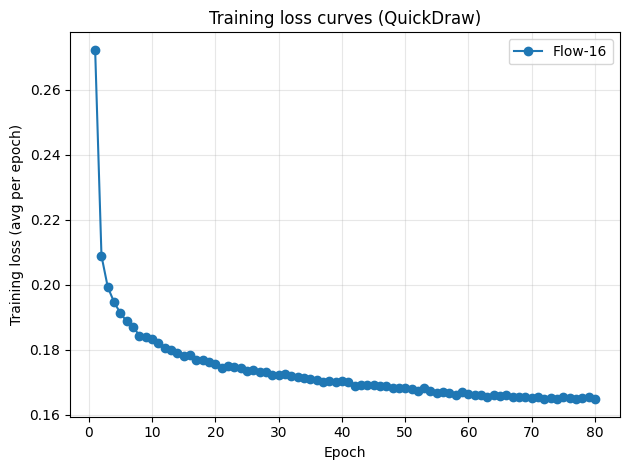

[Figure] Saved loss curves to /content/FastFlowDiff_QuickDraw/figures/training_loss_curves.png


In [ ]:
# ====== Plot training loss curves ======
import matplotlib.pyplot as plt

os.makedirs(FIG_DIR, exist_ok=True)

plt.figure()
if TEACHER_LOSS_HISTORY:
    plt.plot(
        range(1, len(TEACHER_LOSS_HISTORY) + 1),
        TEACHER_LOSS_HISTORY,
        marker="o",
        label="Teacher (DDPM)",
    )
if CONSIST4_LOSS_HISTORY:
    plt.plot(
        range(1, len(CONSIST4_LOSS_HISTORY) + 1),
        CONSIST4_LOSS_HISTORY,
        marker="o",
        label="Consistency-4",
    )
if FLOW_LOSS_HISTORY:
    plt.plot(
        range(1, len(FLOW_LOSS_HISTORY) + 1),
        FLOW_LOSS_HISTORY,
        marker="o",
        label="Flow-16",
    )

plt.xlabel("Epoch")
plt.ylabel("Training loss (avg per epoch)")
plt.title("Training loss curves (QuickDraw)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_fig_path = os.path.join(FIG_DIR, "training_loss_curves.png")
plt.savefig(loss_fig_path, dpi=200)
plt.show()

print(f"[Figure] Saved loss curves to {loss_fig_path}")

In [ ]:
# This cell runs the main evaluation.
# Assumes that teacher, consistency, and flow checkpoints are already trained.

device = DEVICE

# 1. Load models
teacher = load_teacher(device=device)                 # GaussianDiffusion (QuickDraw, 1x32x32, conditional)
consistency_student = load_consistency_4step(device=device)  # Consistency 4-step student
flow_model = load_flow_matching(device=device)        # FlowMatchingModel

# 2. Generate N_EVAL_SAMPLES samples for each model
teacher_samples_dir = os.path.join(SAMPLES_DIR, "teacher_qd")
consist_samples_dir = os.path.join(SAMPLES_DIR, "consistency_4step_qd")
flow16_samples_dir = os.path.join(SAMPLES_DIR, "flow_s16_qd")

# Teacher: N_EVAL_SAMPLES samples
t_teacher_total = generate_samples_teacher(
    diffusion=teacher,
    out_dir=teacher_samples_dir,
    num_samples=N_EVAL_SAMPLES,
    batch_size=EVAL_BATCH_SIZE,
    device=device,
    class_id=None,  # None = Random class
)

# Consistency-4: N_EVAL_SAMPLES samples
t_consist_total = generate_samples_consistency_4step(
    student=consistency_student,
    out_dir=consist_samples_dir,
    num_samples=N_EVAL_SAMPLES,
    batch_size=EVAL_BATCH_SIZE,
    device=device,
    class_id=None,   # None = Random class
)

# Flow-16: N_EVAL_SAMPLES samples
t_flow16_total = generate_samples_flow(
    flow_model=flow_model,
    out_dir=flow16_samples_dir,
    num_samples=N_EVAL_SAMPLES,
    batch_size=EVAL_BATCH_SIZE,
    num_steps=16,
    device=device,
    class_id=None,   # None = Random class
)

time_per_1k_teacher = t_teacher_total / (N_EVAL_SAMPLES / 1000)
time_per_1k_consist = t_consist_total / (N_EVAL_SAMPLES / 1000)
time_per_1k_flow16 = t_flow16_total / (N_EVAL_SAMPLES / 1000)

# 3. Compute FID/IS
m_teacher = compute_fid_is_for_dir(teacher_samples_dir, "Teacher")
m_consist = compute_fid_is_for_dir(consist_samples_dir, "Consistency-4step")
m_flow16 = compute_fid_is_for_dir(flow16_samples_dir, "Flow-16step")

# 4. Small-step latency benchmark (different from the N_EVAL_SAMPLES full run)
def teacher_sample_fn(bs, dev):
    y = torch.randint(0, NUM_QD_CLASSES, (bs,), device=dev)
    return teacher.sample(bs, device=dev, y=y)

def consist_sample_fn(bs, dev):
    y = torch.randint(0, NUM_QD_CLASSES, (bs,), device=dev)
    return consistency_student.sample_4step(bs, device=dev, y=y)

def flow16_sample_fn(bs, dev):
    y = torch.randint(0, NUM_QD_CLASSES, (bs,), device=dev)
    return flow_model.sample(bs, num_steps=16, device=dev, y=y)

bench_teacher = benchmark_sampler(
    teacher_sample_fn,
    batch_size=EVAL_BATCH_SIZE,
    num_batches=10,
    device=device,
)
bench_consist = benchmark_sampler(
    consist_sample_fn,
    batch_size=EVAL_BATCH_SIZE,
    num_batches=10,
    device=device,
)
bench_flow16  = benchmark_sampler(
    flow16_sample_fn,
    batch_size=EVAL_BATCH_SIZE,
    num_batches=10,
    device=device,
)

t_teacher_bench = bench_teacher[0] / (bench_teacher[1] / 1000)
t_consist_bench = bench_consist[0] / (bench_consist[1] / 1000)
t_flow16_bench  = bench_flow16[0]  / (bench_flow16[1]  / 1000)

# 5. Collect results
experiments_latency = [
    {
        "name": "Teacher-1000",
        "nfe": teacher.timesteps,
        "time_1k_full": time_per_1k_teacher,
        "time_1k_bench": t_teacher_bench,
        "fid": m_teacher["fid"],
    },
    {
        "name": "Flow-16",
        "nfe": 16,
        "time_1k_full": time_per_1k_flow16,
        "time_1k_bench": t_flow16_bench,
        "fid": m_flow16["fid"],
    },
    {
        "name": "Consist-4",
        "nfe": 4,
        "time_1k_full": time_per_1k_consist,
        "time_1k_bench": t_consist_bench,
        "fid": m_consist["fid"],
    },
]

print("=== Summary (latency & FID) ===")
for exp in experiments_latency:
    print(exp)

[Teacher] Loaded checkpoint from /content/FastFlowDiff_QuickDraw/teacher_ckpt/teacher_latest.pt
[Consist-4] Loaded checkpoint from /content/FastFlowDiff_QuickDraw/consistency_ckpt/consistency_4step_latest.pt
[Flow] Loaded checkpoint from /content/FastFlowDiff_QuickDraw/flow_ckpt/flow_matching_latest.pt
[Teacher] [1/100] Generated 100/10000 images
[Teacher] [2/100] Generated 200/10000 images
[Teacher] [3/100] Generated 300/10000 images
[Teacher] [4/100] Generated 400/10000 images
[Teacher] [5/100] Generated 500/10000 images
[Teacher] [6/100] Generated 600/10000 images
[Teacher] [7/100] Generated 700/10000 images
[Teacher] [8/100] Generated 800/10000 images
[Teacher] [9/100] Generated 900/10000 images
[Teacher] [10/100] Generated 1000/10000 images
[Teacher] [11/100] Generated 1100/10000 images
[Teacher] [12/100] Generated 1200/10000 images
[Teacher] [13/100] Generated 1300/10000 images
[Teacher] [14/100] Generated 1400/10000 images
[Teacher] [15/100] Generated 1500/10000 images
[Teacher]

Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:02<00:00, 40.4MB/s]
Extracting features from input1
Looking for samples non-recursivelty in "/content/FastFlowDiff_QuickDraw/samples/teacher_qd" with extensions png,jpg,jpeg
Found 10000 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/FastFlowDiff_QuickDraw/quickdraw_real_eval" with extensions png,jpg,jpeg
Found 50000 samples
Processing samples
Inception Score: 2.430825 ± 0.0450704
Frechet Inception Distance: 1.84175
Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']


=== Teacher ===
inception_score_mean: 2.430825149089826
inception_score_std: 0.04507040449486406
frechet_inception_distance: 1.8417501661309075


Extracting features from input1
Looking for samples non-recursivelty in "/content/FastFlowDiff_QuickDraw/samples/consistency_4step_qd" with extensions png,jpg,jpeg
Found 10000 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/FastFlowDiff_QuickDraw/quickdraw_real_eval" with extensions png,jpg,jpeg
Found 50000 samples
Processing samples
Inception Score: 2.459815 ± 0.04226367
Frechet Inception Distance: 17.82586
Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']


=== Consistency-4step ===
inception_score_mean: 2.459814536225823
inception_score_std: 0.042263667032967876
frechet_inception_distance: 17.825856327432774


Extracting features from input1
Looking for samples non-recursivelty in "/content/FastFlowDiff_QuickDraw/samples/flow_s16_qd" with extensions png,jpg,jpeg
Found 10000 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "/content/FastFlowDiff_QuickDraw/quickdraw_real_eval" with extensions png,jpg,jpeg
Found 50000 samples
Processing samples
Inception Score: 2.393949 ± 0.04042466
Frechet Inception Distance: 2.638383


=== Flow-16step ===
inception_score_mean: 2.3939487279788323
inception_score_std: 0.0404246637098081
frechet_inception_distance: 2.6383828841590855
Total 1000 samples in 168.940s, 0.16894 s / sample, 168.940 s / 1000 samples
Total 1000 samples in 0.677s, 0.00068 s / sample, 0.677 s / 1000 samples
Total 1000 samples in 2.697s, 0.00270 s / sample, 2.697 s / 1000 samples
=== Summary (latency & FID) ===
{'name': 'Teacher-1000', 'nfe': 1000, 'time_1k_full': 169.64695422530002, 'time_1k_bench': 168.93984246253967, 'fid': 1.8417501661309075}
{'name': 'Flow-16', 'nfe': 16, 'time_1k_full': 3.4700763210000334, 'time_1k_bench': 2.6970033645629883, 'fid': 2.6383828841590855}
{'name': 'Consist-4', 'nfe': 4, 'time_1k_full': 1.493657677200008, 'time_1k_bench': 0.6773500442504883, 'fid': 17.825856327432774}


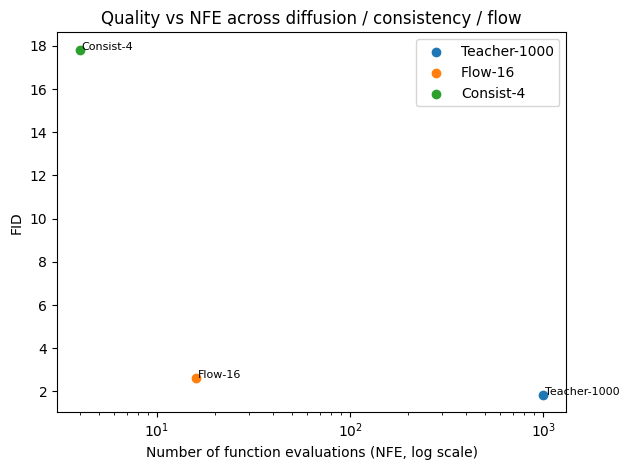

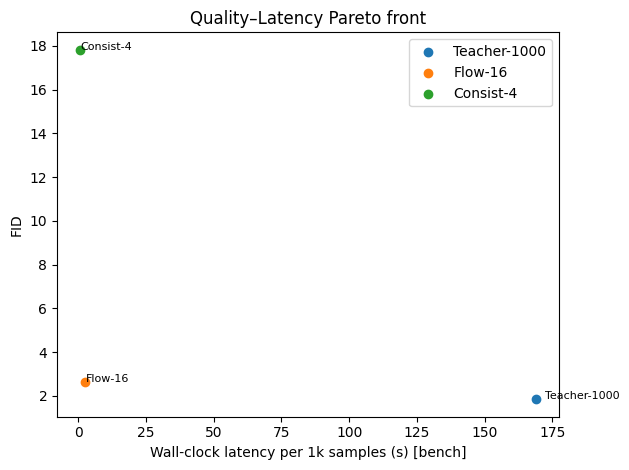

Saved figures to: /content/FastFlowDiff_QuickDraw/figures


In [ ]:
os.makedirs(FIG_DIR, exist_ok=True)

# Quality vs NFE (log-scale x-axis)
plt.figure()
for exp in experiments_latency:
    plt.scatter(exp["nfe"], exp["fid"], label=exp["name"])
    plt.text(exp["nfe"] * 1.02, exp["fid"], exp["name"], fontsize=8)
plt.xscale("log")
plt.xlabel("Number of function evaluations (NFE, log scale)")
plt.ylabel("FID")
plt.title("Quality vs NFE across diffusion / consistency / flow")
plt.legend()
plt.tight_layout()
fig_path_nfe = os.path.join(FIG_DIR, "quality_vs_nfe.png")
plt.savefig(fig_path_nfe, dpi=200)
plt.show()

# Quality–Latency Pareto (using bench time per 1k)
plt.figure()
for exp in experiments_latency:
    plt.scatter(exp["time_1k_bench"], exp["fid"], label=exp["name"])
    plt.text(exp["time_1k_bench"] * 1.02, exp["fid"], exp["name"], fontsize=8)
plt.xlabel("Wall-clock latency per 1k samples (s) [bench]")
plt.ylabel("FID")
plt.title("Quality–Latency Pareto front")
plt.legend()
plt.tight_layout()
fig_path_latency = os.path.join(FIG_DIR, "quality_latency_pareto.png")
plt.savefig(fig_path_latency, dpi=200)
plt.show()

print("Saved figures to:", FIG_DIR)


In [ ]:
# ====== Conditional 3x3 grids for each model + real QuickDraw grid ======
import torch
from torchvision.utils import save_image

os.makedirs(FIG_DIR, exist_ok=True)

# Assuming NUM_QD_CLASSES is 9
CLASS_IDS = list(range(NUM_QD_CLASSES))[:9]  # [0..8]

def make_teacher_class_grid(teacher_model, save_path: str, device: torch.device = DEVICE):
    """
    Sample one image for each of the 9 classes from the Teacher (GaussianDiffusion),
    and arrange them into a 3×3 grid.
    """
    teacher_model.eval()
    with torch.no_grad():
        labels = torch.tensor(CLASS_IDS, device=device, dtype=torch.long)
        imgs = teacher_model.sample(batch_size=len(CLASS_IDS), device=device, y=labels)
        # [-1,1] -> [0,1]
        imgs = (imgs.clamp(-1, 1) + 1) / 2.0
        save_image(imgs, save_path, nrow=3)
    print(f"[Grid] Saved teacher conditional grid to {save_path}")


def make_consistency_class_grid(student_model, save_path: str, device: torch.device = DEVICE):
    """
    Sample one image for each of the 9 classes from the Consistency-4step model.
    """
    student_model.eval()
    with torch.no_grad():
        labels = torch.tensor(CLASS_IDS, device=device, dtype=torch.long)
        imgs = student_model.sample_4step(
            batch_size=len(CLASS_IDS),
            device=device,
            y=labels,
        )
        imgs = (imgs.clamp(-1, 1) + 1) / 2.0
        save_image(imgs, save_path, nrow=3)
    print(f"[Grid] Saved consistency-4 conditional grid to {save_path}")


def make_flow_class_grid(flow_model, save_path: str, num_steps: int = 16, device: torch.device = DEVICE):
    """
    Sample one image for each of the 9 classes from the FlowMatchingModel model.
    """
    flow_model.eval()
    with torch.no_grad():
        labels = torch.tensor(CLASS_IDS, device=device, dtype=torch.long)
        imgs = flow_model.sample(
            batch_size=len(CLASS_IDS),
            num_steps=num_steps,
            device=device,
            y=labels,
        )
        imgs = (imgs.clamp(-1, 1) + 1) / 2.0
        save_image(imgs, save_path, nrow=3)
    print(f"[Grid] Saved flow-16 conditional grid to {save_path}")


def make_real_class_grid(save_path: str, train_split: bool = True, device: torch.device = DEVICE):
    """
    Take one image from each class in the QuickDraw dataset (following the order of `CLASS_IDS`)
    and arrange them into a 3×3 grid of real samples.

    """
    loader = get_quickdraw_dataloader(
        batch_size=128,
        train=train_split,
    )
    dataset = loader.dataset
    print("[Real grid] Dataset classes:", dataset.class_names)

    picked = {}
    for imgs, labels in loader:
        for img, label in zip(imgs, labels):
            cid = int(label.item())
            if cid in CLASS_IDS and cid not in picked:
                picked[cid] = img
            if len(picked) == len(CLASS_IDS):
                break
        if len(picked) == len(CLASS_IDS):
            break

    if len(picked) < len(CLASS_IDS):
        print(f"[Real grid] Warning: only found {len(picked)} / {len(CLASS_IDS)} classes.")

    imgs_list = []
    for cid in CLASS_IDS:
        if cid in picked:
            imgs_list.append(picked[cid])
        else:
            imgs_list.append(torch.zeros_like(next(iter(picked.values()))))

    imgs = torch.stack(imgs_list, dim=0)
    imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
    save_image(imgs, save_path, nrow=3)
    print(f"[Grid] Saved real QuickDraw class grid to {save_path}")

In [ ]:
# ====== Generate per-class 3x3 grids for Teacher / Consistency / Flow / Real ======

teacher_grid_path   = os.path.join(FIG_DIR, "teacher_conditional_grid_3x3.png")
consist_grid_path   = os.path.join(FIG_DIR, "consistency4_conditional_grid_3x3.png")
flow_grid_path      = os.path.join(FIG_DIR, "flow16_conditional_grid_3x3.png")
real_grid_path      = os.path.join(FIG_DIR, "quickdraw_real_grid_3x3.png")

make_teacher_class_grid(teacher, teacher_grid_path, device=device)
make_consistency_class_grid(consistency_student, consist_grid_path, device=device)
make_flow_class_grid(flow_model, flow_grid_path, num_steps=16, device=device)
make_real_class_grid(real_grid_path, train_split=True, device=device)

[Grid] Saved teacher conditional grid to /content/FastFlowDiff_QuickDraw/figures/teacher_conditional_grid_3x3.png
[Grid] Saved consistency-4 conditional grid to /content/FastFlowDiff_QuickDraw/figures/consistency4_conditional_grid_3x3.png
[Grid] Saved flow-16 conditional grid to /content/FastFlowDiff_QuickDraw/figures/flow16_conditional_grid_3x3.png
[QuickDraw] Using classes:
  class 0: airplane.npy
  class 1: apple.npy
  class 2: bicycle.npy
  class 3: bird.npy
  class 4: book.npy
  class 5: car.npy
  class 6: cat.npy
  class 7: chair.npy
  class 8: clock.npy
[QuickDraw] Loaded 81000 images, 9 classes. train=True
[Real grid] Dataset classes: ['airplane.npy', 'apple.npy', 'bicycle.npy', 'bird.npy', 'book.npy', 'car.npy', 'cat.npy', 'chair.npy', 'clock.npy']
[Grid] Saved real QuickDraw class grid to /content/FastFlowDiff_QuickDraw/figures/quickdraw_real_grid_3x3.png


## save

In [ ]:
# Copy samples (this can be large: 3 * 50k images)
copy_item_to_drive(SAMPLES_DIR)

# Copy figures
copy_item_to_drive(FIG_DIR)

print("All main artifacts synchronized to Google Drive:", DRIVE_PROJECT_DIR)


KeyboardInterrupt: 

Note:

Due to time and computation resource constraints, we implemented a simplified version of the consistency model compared with the original paper.

- Limited teacher supervision.
 The original method uses a pre-trained diffusion model for consistency distillation during training. In our implementation, the teacher is only used for weight initialization rather than providing training targets.

- No diffusion trajectory supervision.
 The original method enforces consistency along the same diffusion trajectory generated by the teacher; our version uses independently noised samples.


- Simplified training objective.
 We train the model to predict x0x_0x0​ with an additional consistency regularization between different noise levels.


- Fixed multi-step sampling schedule.
 We use a simple 4-step schedule ( T→0.75T→0.5T→0.25T→0) instead of the adaptive or 1-step sampling discussed in the original paper.


**However, our implementation captures the core idea of consistency regularization while omitting the full distillation pipeline for simplicity.**


